/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Selected features for Cluster 4: ['Liability_to_Equity', 'Degree_of_Financial_Leverage_(DFL)', 'Interest_Coverage_Ratio_(Interest_expense_to_EBIT)', 'Net_Income_Flag', 'Equity_to_Liability']
Cluster 4 Confusion Matrix:
 [[2]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



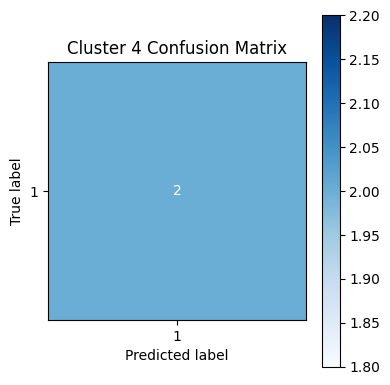

In [ ]:
# Harshil_Chetankumar_Mode_Subgroup4.py

import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, classification_report

# 1) Load data
df = pd.read_csv('train_with_clusters.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_')

# 2) Subset Cluster 4
cluster_id = 4
subgroup = df[df['ClusterID'] == cluster_id]
X = subgroup.drop(columns=['Index', 'ClusterID', 'Bankrupt?'])
y = subgroup['Bankrupt?']

# 3) Feature selection with SelectKBest
k = 5
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X, y)
selected_feats = X.columns[selector.get_support()]

# 4) Write selected features to txt
with open(f"selected_features_cluster{cluster_id}.txt", 'w') as f:
    for feat in selected_feats:
        f.write(f"{feat}\n")
print(f"Selected features for Cluster {cluster_id}: {selected_feats.tolist()}")

# 5) Train an overfit DecisionTree on just those features
model = DecisionTreeClassifier(random_state=42)
model.fit(X[selected_feats], y)
joblib.dump(model, f'stacked_model_cluster{cluster_id}.pkl')

# 6) Evaluate
y_pred = model.predict(X[selected_feats])
cm = confusion_matrix(y, y_pred)
print("Cluster 4 Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y, y_pred, zero_division=0))

# 7) Plot confusion matrix
labels = [1]  # only class '1'
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
ax.figure.colorbar(im, ax=ax)
ax.set_xticks([0]); ax.set_yticks([0])
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
ax.set_title(f'Cluster {cluster_id} Confusion Matrix')
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()
